# 050. 형태소 분석 (POS tag, part-of-speech tag)

- 품사 부착 혹은 POS tag (part-of-speech tag) 라 부름  

- 원시 말뭉치를 형태소 단위로 쪼개고 각 형태소에 품사 정보를 부착하는 작업  

- 형태소는 언어별로 다르고, 비슷한 언어간에는 유사하나 연관성이 없는 단어간에는 완전히 다름  

- 가장 기본적으로는 명사, 동사, 형용사 등으로 나눌 수 있으나 이를 단, 복수형 명사, 동사 변화, 시제 변화 등 더 자세히 나눌 수 있음.  

- 한글의 경우, KoNLPy는 시중에 공개된 꼬꼬마, 코모란, 트위터, 한나눔, 은전한닢 다섯개의 형태소 분석기를 한꺼번에 묶어서 편리하게 사용할 수 있도록 한 패키지

# 형태소의 용도 및 작성법

- 형태소는 각 단어가 어떤 품사인지 고려하여 자동 문장 처리를 가능하도록 한다.  이를 이용하여 언어의 통계적 처리가 가능  

- 영어와 같이 동일한 단어가 다른 품사를 가지는 언어의 경우 품사 tagging 에 의해 그 단어가 명사로 사용 되었는지 동사로 사용되었는지 구분할 수 있다.  

- 수작업 tagging 은 large corpus 에서는 거의 불가능하고, small corpus 에서 training data 용으로 사용  

- 여러 언어를 처리하는 tagger 도 있으나, 각 언어별 tagger 들은 서로 관련성 없을 수 있고, 각각 다른 접근법과 알고리즘 및 프로그램 언어를 사용할 수 있다.

## Keras 를 이용한 LSTM POS tagger 작성

- Bidirectional LSTM 으로 POS tagger 작성  


- nltk 내장 corpus 를 이용하여 training  
    - nltk.corpus.treebank.tagged_sents() 사용

In [ ]:
!pip install konlpy

In [ ]:
!pip install sklearn

In [7]:
!pip install nltk

In [8]:
import re
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Embedding, Activation
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
import nltk
from konlpy.tag import Okt

In [9]:
nltk.download('treebank')

[nltk_data] Downloading package treebank to
[nltk_data]     C:\Users\trimu\AppData\Roaming\nltk_data...
[nltk_data]   Package treebank is already up-to-date!


True

In [10]:
tagged_sentences = nltk.corpus.treebank.tagged_sents()

print(tagged_sentences[100])
print()
print(' '.join([word for (word, tag) in tagged_sentences[100]]))
print()
print("Total tagged sentences :", len(tagged_sentences))
print("Total tagged words :", len(nltk.corpus.treebank.tagged_words()))

[('Alan', 'NNP'), ('Spoon', 'NNP'), (',', ','), ('recently', 'RB'), ('named', 'VBN'), ('*', '-NONE-'), ('Newsweek', 'NNP'), ('president', 'NN'), (',', ','), ('said', 'VBD'), ('0', '-NONE-'), ('Newsweek', 'NNP'), ("'s", 'POS'), ('ad', 'NN'), ('rates', 'NNS'), ('would', 'MD'), ('increase', 'VB'), ('5', 'CD'), ('%', 'NN'), ('in', 'IN'), ('January', 'NNP'), ('.', '.')]

Alan Spoon , recently named * Newsweek president , said 0 Newsweek 's ad rates would increase 5 % in January .

Total tagged sentences : 3914
Total tagged words : 100676


### input, label data 작성을 위해 단어와 tag 를 분리

In [11]:
sentences, sentence_tags =[], [] 

for tagged_sentence in tagged_sentences:
    sentence, tags = zip(*tagged_sentence)
    sentences.append(list(sentence))
    sentence_tags.append(list(tags))

# Let's see how a sequence looks
print(sentences[5])
print(sentence_tags[5])

['Lorillard', 'Inc.', ',', 'the', 'unit', 'of', 'New', 'York-based', 'Loews', 'Corp.', 'that', '*T*-2', 'makes', 'Kent', 'cigarettes', ',', 'stopped', 'using', 'crocidolite', 'in', 'its', 'Micronite', 'cigarette', 'filters', 'in', '1956', '.']
['NNP', 'NNP', ',', 'DT', 'NN', 'IN', 'JJ', 'JJ', 'NNP', 'NNP', 'WDT', '-NONE-', 'VBZ', 'NNP', 'NNS', ',', 'VBD', 'VBG', 'NN', 'IN', 'PRP$', 'NN', 'NN', 'NNS', 'IN', 'CD', '.']


샘플의 최대 길이 : 271
샘플의 평균 길이 : 25.722024


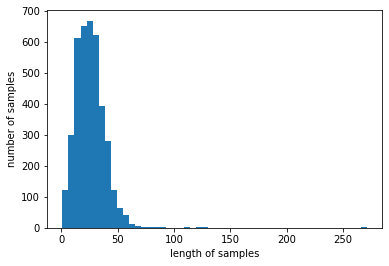

In [12]:
print('샘플의 최대 길이 : {}'.format(max([len(w) for w in sentences])))
print('샘플의 평균 길이 : {:4f}'.format(np.mean([len(w) for w in sentences])))
plt.hist([len(s) for s in sentences], bins=50)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

**sample 들의 길이가 대체적으로 0-100의 길이를 가지며, 특히 0-50의 길이를 가진 샘플이 상당한 비율을 차지**

**keras 는 fixed size sequence 만 handling 가능하므로 max sequence length 를 100 으로 정함**

In [13]:
MAX_LENGTH = 100

### 전체 word 수 check

In [14]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(sentences)

print(len(tokenizer.word_index))

11387


**전체 token 갯수가 11387 개 이므로 상위 4000 개로 제한하여 vocabulary 재작성**

- 문장 데이터에 대해서는 input_tokenizer를, 레이블에 해당되는 개체명 태깅 정보에 대해서는 tag_tokenizer를 사용  

In [15]:
MAX_WORDS = 4000

### train, test split

In [16]:
train_sentences, test_sentences, train_tags, test_tags = train_test_split(sentences, sentence_tags, test_size=0.2)

### train data 는 train_sentences 에 대해 tokenize 하고 label 은 전체 sentence_tags 에 대해 tokenize

- model 은 train 시 validation data 를 볼 수 없어야 함

In [17]:
input_tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
input_tokenizer.fit_on_texts(train_sentences)

tag_tokenizer = Tokenizer()
tag_tokenizer.fit_on_texts(sentence_tags)

vocab_size = input_tokenizer.num_words + 1
tag_size = len(tag_tokenizer.word_index) + 1

print('단어 집합의 크기 : {}'.format(vocab_size))
print('개체명 태깅 정보 집합의 크기 : {}'.format(tag_size))

단어 집합의 크기 : 4001
개체명 태깅 정보 집합의 크기 : 47


### sentence 와 tag 를 sequence 로 변환

In [18]:
X_train = input_tokenizer.texts_to_sequences(train_sentences)
y_train = tag_tokenizer.texts_to_sequences(train_tags)

X_test = input_tokenizer.texts_to_sequences(test_sentences)
y_test = tag_tokenizer.texts_to_sequences(test_tags)

- sequence padding

In [19]:
train_sentences_X = pad_sequences(X_train, maxlen=MAX_LENGTH, padding='post')
test_sentences_X = pad_sequences(X_test, maxlen=MAX_LENGTH, padding='post')
train_tags_y = pad_sequences(y_train, maxlen=MAX_LENGTH, padding='post')
test_tags_y = pad_sequences(y_test, maxlen=MAX_LENGTH, padding='post')
 
print(train_sentences_X[0])
print(test_sentences_X[0])
print(train_tags_y[0])
print(test_tags_y[0])

[1013  167   33 1472   19   32 1014   14    1    2    9  158   62 3239
  251  763   12    6  141   32    7 3240    1    2   20   50   11  102
  620  837 2492    2   67    5  934  155  293   96    2    7 2493  252
   15   16 1126    7   18 1015   35   17  530   15   37 1473  118  435
    4    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]
[  78  314    9    1  131  362   10 1699    4    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0

### n-to-n model 이므로 return_sequences=True 로 설정

In [22]:
def pos_model():
    model = Sequential()
    model.add(Embedding(vocab_size, 128))
    model.add(Bidirectional(LSTM(256, return_sequences=True)))
    model.add(Dense(tag_size))
    model.add(Activation('softmax'))

    model.compile(loss='categorical_crossentropy', optimizer=Adam(0.001), metrics=['accuracy'])

    model.summary()
    return model

model = pos_model()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_1 (Embedding)      (None, None, 128)         512128    
_________________________________________________________________
bidirectional_1 (Bidirection (None, None, 512)         788480    
_________________________________________________________________
dense_1 (Dense)              (None, None, 47)          24111     
_________________________________________________________________
activation_1 (Activation)    (None, None, 47)          0         
Total params: 1,324,719
Trainable params: 1,324,719
Non-trainable params: 0
_________________________________________________________________


In [23]:
cat_train_tags_y = to_categorical(train_tags_y, tag_size)
cat_test_tags_y = to_categorical(test_tags_y, tag_size)

print(cat_train_tags_y[0])

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]]


In [ ]:
model.fit(train_sentences_X, cat_train_tags_y , batch_size=128, epochs=40, 
                          validation_data=(test_sentences_X, cat_test_tags_y ))

In [26]:
model.metrics_names

['loss', 'accuracy']

In [27]:
scores = model.evaluate(test_sentences_X, cat_test_tags_y, verbose=0)
print(f"{model.metrics_names[1]}: {scores[1] * 100}")   # acc: 99.09751977804825

accuracy: 97.65133857727051


In [48]:
test_samples = [
     "running is very important to me .".split(),
    "I was running every day for a month .".split()
]
print(test_samples)

[['running', 'is', 'very', 'important', 'to', 'me', '.'], ['I', 'was', 'running', 'every', 'day', 'for', 'a', 'month', '.']]


In [49]:
test_samples_X = input_tokenizer.texts_to_sequences(test_samples)
test_samples_X = pad_sequences(test_samples_X, maxlen=MAX_LENGTH, padding='post')

In [50]:
test_samples_X

array([[2009,   21,  372,  668,    6, 1301,    4,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0],
       [  84,   34, 2009,  678,  442,   14,    7,  204,    4,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    

In [51]:
index2word = input_tokenizer.index_word
index2tag = tag_tokenizer.index_word

In [60]:
y_predicted = model.predict_classes(test_samples_X)

In [61]:
y_predicted

array([[ 3, 17, 12,  7, 15, 18,  9,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0],
       [18, 11, 19,  4,  1,  2,  4,  1,  9,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0]], dtype=int64)

In [63]:
for i in range(len(test_samples_X)):
    for w, t in zip([index2word.get(x, '?') for x in test_samples_X[i]], 
                    [index2tag.get(y, '?') for y in y_predicted[i]]):
        if w != '<OOV>' and w != '?' and t !='?':
            print(f'{w} : {t.upper()}')
    print()

running : NNP
is : VBZ
very : RB
important : JJ
to : TO
me : PRP
. : .

i : PRP
was : VBD
running : VBG
every : DT
day : NN
for : IN
a : DT
month : NN
. : .



In [56]:
print(nltk.pos_tag(test_samples[0]))
print(nltk.pos_tag(test_samples[1]))

[('running', 'NN'), ('is', 'VBZ'), ('very', 'RB'), ('important', 'JJ'), ('to', 'TO'), ('me', 'PRP'), ('.', '.')]
[('I', 'PRP'), ('was', 'VBD'), ('running', 'VBG'), ('every', 'DT'), ('day', 'NN'), ('for', 'IN'), ('a', 'DT'), ('month', 'NN'), ('.', '.')]


## 한글 품사 tagging

- Okt 를 이용  

- 한글 어린왕자 corpus 이용  

In [66]:
okt = Okt()

f = open("data/young_prince.txt", encoding="utf-8")
text = f.readlines()
text[:2]

['여섯 살 적에 나는 "체험한 이야기"라는 제목의, 원시림에 관한 책에서 기막힌 그림 하나를 본 적이 있다. 맹수를 집어삼키고 있는 보아 구렁이 그림이었다. 위의 그림은 그것을 옮겨 그린 것이다.\n',
 '  그 책에는 이렇게 씌어 있었다.\n']

In [69]:
tagged_sentences= []

for line in text:
    line = re.sub(r'[^가-힣ㄱ-ㅎㅏ-ㅣ ]', '', line)
    line = okt.pos(line)
    if len(line) > 0:
        tagged_sentences.append(line)

print(len(tagged_sentences))

951


In [70]:
pos_tags = []

for sentence in tagged_sentences:
    for pos_tag in sentence:
        pos_tags.append(pos_tag)
        
print(' '.join([word for (word, tag) in tagged_sentences[100]]))
print()
print("Total tagged sentences :", len(tagged_sentences))
print("Total tagged words :", len(pos_tags))

한 떼 의 코끼리 라는 말 에 어린 왕자 는 웃으며

Total tagged sentences : 951
Total tagged words : 16477


In [71]:
sentences, sentence_tags =[], [] 

for tagged_sentence in tagged_sentences:
    sentence, tags = zip(*tagged_sentence)
    sentences.append(list(sentence))
    sentence_tags.append(list(tags))

# Let's see how a sequence looks
print(sentences[5])
print(sentence_tags[5])

['그', '들', '은', '모자', '가', '뭐', '가', '무섭다는', '거니', '하고', '대답', '했다']
['Noun', 'Suffix', 'Josa', 'Noun', 'Josa', 'Noun', 'Josa', 'Adjective', 'Eomi', 'Verb', 'Noun', 'Verb']


샘플의 최대 길이 : 184
샘플의 평균 길이 : 17.325973


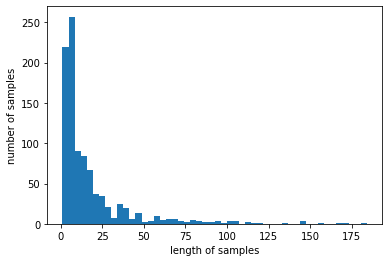

In [72]:
print('샘플의 최대 길이 : {}'.format(max(len(w) for w in sentences)))
print('샘플의 평균 길이 : {:4f}'.format(sum(map(len, sentences))/len(sentences)))
plt.hist([len(s) for s in sentences], bins=50)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

In [73]:
MAX_LENGTH = 100

In [74]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(sentences)

print(len(tokenizer.word_index))

3419


In [75]:
MAX_WORDS = 3000

In [76]:
from sklearn.model_selection import train_test_split
 
train_sentences, test_sentences, train_tags, test_tags = train_test_split(sentences, sentence_tags, test_size=0.2)

In [77]:
input_tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
input_tokenizer.fit_on_texts(train_sentences)

tag_tokenizer = Tokenizer()
tag_tokenizer.fit_on_texts(sentence_tags)

vocab_size = input_tokenizer.num_words + 1
tag_size = len(tag_tokenizer.word_index) + 1
print('단어 집합의 크기 : {}'.format(vocab_size))
print('개체명 태깅 정보 집합의 크기 : {}'.format(tag_size))

단어 집합의 크기 : 3001
개체명 태깅 정보 집합의 크기 : 13


In [78]:
X_train = input_tokenizer.texts_to_sequences(train_sentences)
y_train = tag_tokenizer.texts_to_sequences(train_tags)

X_test = input_tokenizer.texts_to_sequences(test_sentences)
y_test = tag_tokenizer.texts_to_sequences(test_tags)

In [79]:
train_sentences_X = pad_sequences(X_train, maxlen=MAX_LENGTH, padding='post')
test_sentences_X = pad_sequences(X_test, maxlen=MAX_LENGTH, padding='post')
train_tags_y = pad_sequences(y_train, maxlen=MAX_LENGTH, padding='post')
test_tags_y = pad_sequences(y_test, maxlen=MAX_LENGTH, padding='post')
 
print(train_sentences_X[100])
print(test_sentences_X[100])
print(train_tags_y[100])
print(test_tags_y[100])

[  15   16    4  104   33  450   48    5    4   39  152  280    2  451
  771  172  173  174   18    3  317   13  772  375  560   39  452   13
 1320  224  561  562   26 1321   15   16    4    5  773    3 1322    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]
[ 399   15   16    4  288   35    1 1534   13   82   31    1   22    2
    1  271  205   12    5    4    1  330   10    8    2    1    1  149
    1    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0

In [80]:
kor_model = pos_model()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_2 (Embedding)      (None, None, 128)         384128    
_________________________________________________________________
bidirectional_2 (Bidirection (None, None, 512)         788480    
_________________________________________________________________
dense_2 (Dense)              (None, None, 13)          6669      
_________________________________________________________________
activation_2 (Activation)    (None, None, 13)          0         
Total params: 1,179,277
Trainable params: 1,179,277
Non-trainable params: 0
_________________________________________________________________


In [81]:
cat_train_tags_y = to_categorical(train_tags_y, tag_size)
cat_test_tags_y = to_categorical(test_tags_y, tag_size)
print(cat_train_tags_y[0])

[[0. 1. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]]


In [ ]:
kor_model.fit(train_sentences_X, cat_train_tags_y , batch_size=128, epochs=40, 
              validation_data=(test_sentences_X, cat_test_tags_y ))

In [83]:
scores = kor_model.evaluate(test_sentences_X, cat_test_tags_y, verbose=0)
print(f"{model.metrics_names[1]}: {scores[1] * 100}")   

accuracy: 96.90052270889282


In [84]:
test_samples = [
     "한 떼 의 코끼리 라는 말 에 어린 왕자 는 웃으며"
]
print(test_samples)

['한 떼 의 코끼리 라는 말 에 어린 왕자 는 웃으며']


In [85]:
test_samples_X = input_tokenizer.texts_to_sequences(test_samples)
test_samples_X = pad_sequences(test_samples_X, maxlen=MAX_LENGTH, padding='post')

In [86]:
index2word = input_tokenizer.index_word
index2tag = tag_tokenizer.index_word

In [90]:
predictions = kor_model.predict_classes(test_samples_X)

In [91]:
for i in range(len(test_samples_X)):
    for w, t in zip([index2word.get(x, '?') for x in test_samples_X[i]], [index2tag.get(y, '?') for y in y_predicted[i]]):
        if w != '<OOV>' and w != '?' and t !='?':
            print(f'{w} : {t.upper()}')
    print()

한 : VERB
떼 : NOUN
의 : JOSA
코끼리 : NOUN
라는 : JOSA
말 : NOUN
에 : JOSA
어린 : VERB
왕자 : NOUN
는 : JOSA
웃으며 : VERB



In [92]:
okt.pos(test_samples[0])

[('한', 'Verb'),
 ('떼', 'Noun'),
 ('의', 'Noun'),
 ('코끼리', 'Noun'),
 ('라는', 'Josa'),
 ('말', 'Noun'),
 ('에', 'Josa'),
 ('어린', 'Verb'),
 ('왕자', 'Noun'),
 ('는', 'Verb'),
 ('웃으며', 'Verb')]